In [1]:
with open('shakespeare.txt', 'r',encoding='utf-8') as f:
    text = f.read()

print(text[:100])
print(len(text))

chars = sorted(list(set(text)))
chars_to_idx = {ch: idx for idx, ch in enumerate(chars)}
idx_to_chars = {idx: ch for idx, ch in enumerate(chars)}

print(len(chars))
print(list(chars_to_idx.items())[:10])
print(list(idx_to_chars.items())[:10])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
1115394
65
[('\n', 0), (' ', 1), ('!', 2), ('$', 3), ('&', 4), ("'", 5), (',', 6), ('-', 7), ('.', 8), ('3', 9)]
[(0, '\n'), (1, ' '), (2, '!'), (3, '$'), (4, '&'), (5, "'"), (6, ','), (7, '-'), (8, '.'), (9, '3')]


In [2]:
import numpy as np

text_as_int = np.array([chars_to_idx[c] for c in text])
print(len(text_as_int))

1115394


In [3]:
import torch
from torch.utils.data import DataLoader, Dataset

seq_length = 100
batch_size = 64

class ShakeSpeareDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        self.text_as_int = text_as_int
        self.seq_length = seq_length
        self.sub_len = seq_length + 1

    def __len__(self):
        return len(self.text_as_int)//(self.seq_length+1)

    def __getitem__(self, idx):
        return torch.tensor(self.text_as_int[idx*self.sub_len:(idx+1)*self.sub_len], dtype=torch.long)

def collate_fct(batch):
    batch = torch.stack(batch)
    input_batch = batch[:, :-1]
    target_batch = batch[:, 1:]
    return input_batch, target_batch

shakespeare_dataset = ShakeSpeareDataset(text_as_int, seq_length)
dataloader = DataLoader(shakespeare_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fct,drop_last=True)
for input_batch, target_batch in dataloader:
    print(input_batch.shape)
    print(target_batch.shape)

    print(input_batch)
    print(target_batch)
    break

print(len(shakespeare_dataset))
print(len(dataloader))

torch.Size([64, 100])
torch.Size([64, 100])
tensor([[46, 53, 61,  ..., 52, 42,  6],
        [56, 43,  1,  ..., 46, 63,  6],
        [39, 49,  1,  ..., 50, 43, 58],
        ...,
        [47, 50, 42,  ..., 56,  1, 53],
        [31, 10,  0,  ..., 56,  1, 24],
        [ 6,  1, 58,  ..., 10,  1, 50]])
tensor([[53, 61,  1,  ..., 42,  6,  1],
        [43,  1, 57,  ..., 63,  6,  1],
        [49,  1, 53,  ..., 43, 58, 57],
        ...,
        [50, 42, 47,  ...,  1, 53, 44],
        [10,  0, 31,  ...,  1, 24, 59],
        [ 1, 58, 46,  ...,  1, 50, 43]])
11043
172


In [4]:
import torch.nn as nn
import torch.nn.functional as F

class ShakesphereRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, batch_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        self.dense = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        output = self.dense(output)
        return output, hidden

vocab_size = len(chars_to_idx)
embedding_dim = 256
rnn_units = 1024

model = ShakesphereRNN(vocab_size, embedding_dim, rnn_units, batch_size)
print(model)

ShakesphereRNN(
  (embedding): Embedding(65, 256)
  (rnn): LSTM(256, 1024, batch_first=True)
  (dense): Linear(in_features=1024, out_features=65, bias=True)
)


In [5]:
sample_input = torch.randint(0, vocab_size, (batch_size, seq_length), dtype=torch.long)
sample_output, sample_hidden = model(sample_input)
print(sample_input.shape)
print(sample_output.shape)

torch.Size([64, 100])
torch.Size([64, 100, 65])


In [6]:
from tqdm.auto import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_step(model, dataloader, optimizer, criterion, epochs=5):
    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        with tqdm(dataloader, desc=f"轮次 {epoch+1}/{epochs}") as pbar:
            for input_batch, target_batch in pbar:
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                optimizer.zero_grad()

                output, _ = model(input_batch)

                output = output.reshape(-1, vocab_size)
                target_batch = target_batch.reshape(-1)

                loss = criterion(output, target_batch)

                loss.backward()
                optimizer.step()

                current_loss = loss.item()
                epoch_loss += current_loss

                pbar.set_postfix({"损失": f"{current_loss:.4f}"})

        avg_epoch_loss = epoch_loss / len(dataloader)
        losses.append(avg_epoch_loss)
        print(f"轮次 {epoch+1}/{epochs} 完成, 平均损失: {avg_epoch_loss:.4f}")

    return losses

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

losses = train_step(model, dataloader, optimizer, criterion, epochs=5)

轮次 1/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 1/5 完成, 平均损失: 2.0587


轮次 2/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 2/5 完成, 平均损失: 1.5435


轮次 3/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 3/5 完成, 平均损失: 1.4151


轮次 4/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 4/5 完成, 平均损失: 1.3448


轮次 5/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 5/5 完成, 平均损失: 1.2957


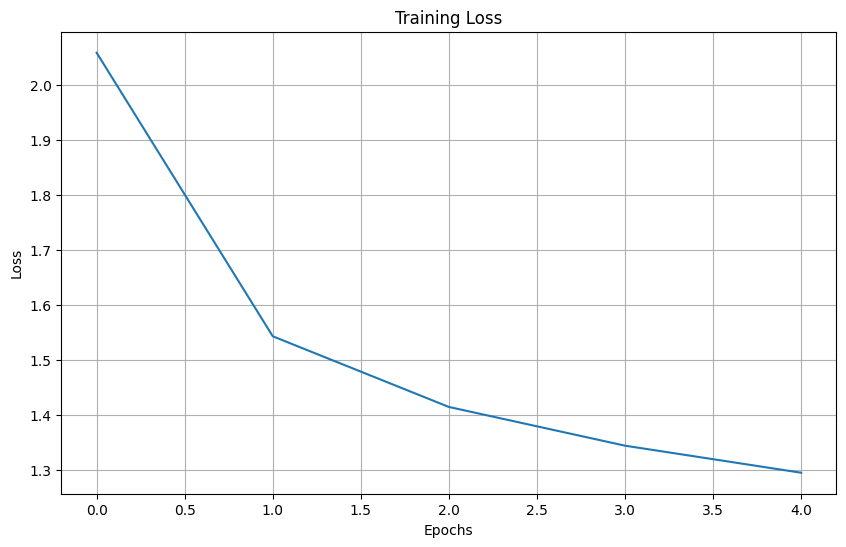

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [8]:
import torch
import torch.nn.functional as F


probs = torch.tensor([0.1, 0.2, 0.3, 0.4])
print("概率分布:", probs)

sample = torch.multinomial(probs, num_samples=1)
print("采样一个元素:", sample.item(), "对应概率:", probs[sample.item()].item())

概率分布: tensor([0.1000, 0.2000, 0.3000, 0.4000])
采样一个元素: 3 对应概率: 0.4000000059604645


原始logits值: tensor([1.0000, 2.0000, 5.0000, 3.0000, 0.5000])

temperature=0.5时的概率分布:
tensor([3.2848e-04, 2.4272e-03, 9.7919e-01, 1.7934e-02, 1.2084e-04])

temperature=1.0时的概率分布:
tensor([0.0151, 0.0410, 0.8234, 0.1114, 0.0091])

temperature=2.0时的概率分布:
tensor([0.0739, 0.1218, 0.5459, 0.2008, 0.0575])


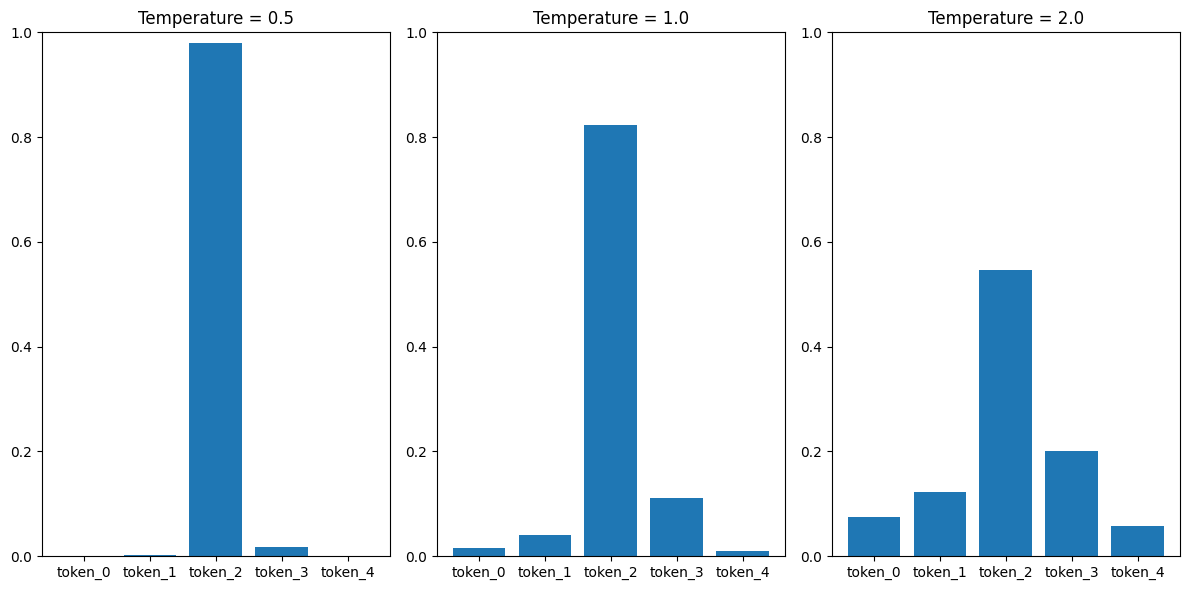

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

logits = torch.tensor([1.0, 2.0, 5.0, 3.0, 0.5])
print("原始logits值:", logits)

temperatures = [0.5, 1.0, 2.0]

plt.figure(figsize=(12, 6))

for i, temp in enumerate(temperatures):
    scaled_logits = logits / temp

    probabilities = F.softmax(scaled_logits, dim=0)

    print(f"\ntemperature={temp}时的概率分布:")
    print(probabilities)

    plt.subplot(1, len(temperatures), i+1)
    plt.bar(range(len(probabilities)), probabilities.numpy())
    plt.title(f"Temperature = {temp}")
    plt.ylim(0, 1)
    plt.xticks(range(len(probabilities)), [f"token_{i}" for i in range(len(probabilities))])

plt.tight_layout()
plt.show()

In [10]:
def generate_text(model, start_string, char2idx, idx2char, num_generate=1000, temperature=1.0):
    model.eval()

    input_indices = [char2idx[char] for char in start_string]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device) #unsqueeze(0) 在第0维上增加一个维度
    print(input_tensor.shape)
    generated_text = start_string

    hidden = None

    with torch.no_grad():
        for _ in range(num_generate):
            output, hidden = model(input_tensor,hidden)
            logits = output[:, -1, :] / temperature

            probabilities = F.softmax(logits, dim=-1)
            predicted_id = torch.multinomial(probabilities, 1)

            generated_char = idx2char[predicted_id.item()]
            generated_text += generated_char

            input_tensor = predicted_id

    return generated_text

generate_text(model, 'hello',chars_to_idx,idx_to_chars)

torch.Size([1, 5])


"hellow\nThat comint all fortentable to myself.\n\nCOMINIUS:\nNay, brame it you that lived, the lick of one?\n\nFRIAR LAURENCE:\nNo, my good lord, afray, and bear him aw;\nAnd, for the crossing to take on him,\nEnfold the streeks on oath that you our degs:\nI will stoop the vew to friends them point.\n\nARIEL:\nHold with a man, she day get themselves,\nthumb at his request: the trit, his upon hold the heart!\n\nKATHARINA:\nI musty die! but that I be any garant,\nThat had had nor hoth of dear you thus that hand\nTo seem theysangs to your higndesfest unupposet.\nI say to meet sirror shall I be a mellow!\n\nPOLIXENES:\nPray nor hence;\nGo not; a better father pleasure us in him, the\nprincely sent.\n\nSecond Citizen:\nNow call, the door sir, and you will see him falsely died.:\nTo be askundy? I am as a mad?\n\nCOMINIUS:\nMy post, good yough: on take no gold,\nMean the law rank'st; an have we fear'd,\nAm me say 'tis go orce passed: the Romeobers,\nWas it to fool the winds heavy given by ni